In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import zipfile
import os

zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


In [ ]:
import os

DATASET_DIR = "/content/dataset/dataset_raw"

print("Folder dataset:", os.listdir(DATASET_DIR))
print("Jumlah foto spoon:", len(os.listdir(os.path.join(DATASET_DIR, "spoon"))))
print("Jumlah foto fork:", len(os.listdir(os.path.join(DATASET_DIR, "fork"))))

Folder dataset: ['fork', 'spoon']
Jumlah foto spoon: 151
Jumlah foto fork: 199


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Lokasi dataset asli
DATASET_DIR = "/content/dataset/dataset_raw"

# Lokasi hasil split
SPLIT_DIR = "/content/dataset_split"

# Ekstensi gambar yang diterima
IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".php", ".ashx"
)

classes = ["spoon", "fork"]

# Hapus hasil split lama saja
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Buat folder train dan val
for split in ["train", "val"]:
    for cls in classes:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, cls),
            exist_ok=True
        )

# Proses pembagian dataset
for cls in classes:

    source_dir = os.path.join(DATASET_DIR, cls)

    files = sorted([
        f for f in os.listdir(source_dir)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ])

    train_files, val_files = train_test_split(
        files,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    # Salin gambar training
    for f in train_files:
        shutil.copy2(
            os.path.join(source_dir, f),
            os.path.join(SPLIT_DIR, "train", cls, f)
        )

    # Salin gambar validation
    for f in val_files:
        shutil.copy2(
            os.path.join(source_dir, f),
            os.path.join(SPLIT_DIR, "val", cls, f)
        )

    print(f"\nKelas: {cls}")
    print(f"Total gambar : {len(files)}")
    print(f"Train        : {len(train_files)}")
    print(f"Validation   : {len(val_files)}")

print("\nPembagian dataset selesai!")


Kelas: spoon
Total gambar : 151
Train        : 120
Validation   : 31

Kelas: fork
Total gambar : 199
Train        : 159
Validation   : 40

Pembagian dataset selesai!


In [ ]:
for split in ["train", "val"]:
    print(f"\n{split.upper()}")

    for cls in classes:
        folder = os.path.join(SPLIT_DIR, split, cls)

        total = len([
            f for f in os.listdir(folder)
            if os.path.isfile(os.path.join(folder, f))
        ])

        print(f"{cls}: {total} gambar")


TRAIN
spoon: 120 gambar
fork: 159 gambar

VAL
spoon: 31 gambar
fork: 40 gambar


In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random
import numpy as np

# Mengatur seed agar eksperimen lebih mudah direproduksi
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

print("GPU tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
GPU tersedia: False


In [ ]:
# Normalisasi ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Transformasi untuk training
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transformasi untuk validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

print("Transformasi training dan validation berhasil dibuat!")

Transformasi training dan validation berhasil dibuat!


In [ ]:
# Lokasi dataset hasil split
SPLIT_DIR = "/content/dataset_split"

# Ekstensi gambar termasuk file JPEG dengan ekstensi nonstandar
valid_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".php", ".ashx"
)

def is_valid_image(path):
    return path.lower().endswith(valid_extensions)

# Membaca dataset
train_dataset = datasets.ImageFolder(
    root=f"{SPLIT_DIR}/train",
    transform=train_transform,
    is_valid_file=is_valid_image
)

val_dataset = datasets.ImageFolder(
    root=f"{SPLIT_DIR}/val",
    transform=val_transform,
    is_valid_file=is_valid_image
)

# Membuat DataLoader
BATCH_SIZE = 32

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Class mapping:", train_dataset.class_to_idx)
print("Jumlah data training:", len(train_dataset))
print("Jumlah data validation:", len(val_dataset))
print("Jumlah batch training:", len(train_loader))
print("Jumlah batch validation:", len(val_loader))

Class mapping: {'fork': 0, 'spoon': 1}
Jumlah data training: 279
Jumlah data validation: 71
Jumlah batch training: 9
Jumlah batch validation: 3


In [ ]:
# Ambil satu batch data training
images, labels = next(iter(train_loader))

print("Shape images:", images.shape)
print("Shape labels:", labels.shape)

print("Label dalam batch:", labels)

print("Nilai minimum tensor:", images.min().item())
print("Nilai maksimum tensor:", images.max().item())

Shape images: torch.Size([32, 3, 224, 224])
Shape labels: torch.Size([32])
Label dalam batch: tensor([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
        1, 0, 0, 1, 0, 1, 0, 0])
Nilai minimum tensor: -2.1179039478302
Nilai maksimum tensor: 2.640000104904175


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Menentukan perangkat komputasi
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [ ]:
def build_model(mode):
    # Memuat model berdasarkan skenario eksperimen
    if mode == "scratch":
        model = models.mobilenet_v3_large(weights=None)
    else:
        model = models.mobilenet_v3_large(
            weights=models.MobileNet_V3_Large_Weights.DEFAULT
        )

    # Mengganti classifier untuk 2 kelas
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 2)

    # Mengatur layer yang dapat dilatih
    if mode == "feature":
        for param in model.parameters():
            param.requires_grad = False

        for param in model.classifier.parameters():
            param.requires_grad = True

    elif mode == "partial":
        for param in model.parameters():
            param.requires_grad = False

        # Membuka feature block terakhir
        for param in model.features[-1].parameters():
            param.requires_grad = True

        # Membuka classifier
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif mode == "scratch":
        for param in model.parameters():
            param.requires_grad = True

    else:
        raise ValueError("Mode tidak dikenal")

    return model

In [ ]:
modes = ["feature", "partial", "scratch"]

for mode in modes:
    model = build_model(mode)

    total_params = sum(
        p.numel() for p in model.parameters()
    )

    trainable_params = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )

    print(f"\nMode: {mode}")
    print(f"Total parameter    : {total_params:,}")
    print(f"Trainable parameter: {trainable_params:,}")
    print(f"Frozen parameter   : {total_params - trainable_params:,}")

    del model

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 208MB/s]



Mode: feature
Total parameter    : 4,204,594
Trainable parameter: 1,232,642
Frozen parameter   : 2,971,952

Mode: partial
Total parameter    : 4,204,594
Trainable parameter: 1,388,162
Frozen parameter   : 2,816,432

Mode: scratch
Total parameter    : 4,204,594
Trainable parameter: 4,204,594
Frozen parameter   : 0


In [ ]:
import time
import copy
import torch

def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,
                num_epochs=10):

    model = model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        start_time = time.time()

        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for phase in ["train", "val"]:

            if phase == "train":
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            total_samples = 0

            for images, labels in dataloader:

                images = images.to(device)
                labels = labels.to(device)

                if phase == "train":
                    optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                batch_size = labels.size(0)

                running_loss += loss.item() * batch_size
                running_corrects += torch.sum(
                    preds == labels
                ).item()

                total_samples += batch_size

            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects / total_samples

            if phase == "train":
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc)
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc)

                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

            print(
                f"{phase.capitalize()} Loss: {epoch_loss:.4f} | "
                f"Accuracy: {epoch_acc:.4f}"
            )

        scheduler.step()

        elapsed = time.time() - start_time
        print(f"Waktu epoch: {elapsed:.2f} detik")

    model.load_state_dict(best_model_wts)

    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

    return model, history

In [ ]:
model_feature = build_model("feature")

model_feature = model_feature.to(device)

optimizer_feature = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_feature.parameters()),
    lr=1e-3
)

scheduler_feature = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_feature,
    T_max=10
)

criterion = nn.CrossEntropyLoss()

model_feature, history_feature = train_model(
    model=model_feature,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_feature,
    scheduler=scheduler_feature,
    num_epochs=10
)

torch.save(
    model_feature.state_dict(),
    "/content/mobilenetv3_feature.pth"
)

print("Model Feature Extraction berhasil disimpan!")


Epoch 1/10
Train Loss: 0.5668 | Accuracy: 0.7133
Val Loss: 0.2356 | Accuracy: 0.9577
Waktu epoch: 11.71 detik

Epoch 2/10
Train Loss: 0.4550 | Accuracy: 0.7742
Val Loss: 0.3071 | Accuracy: 0.8451
Waktu epoch: 11.53 detik

Epoch 3/10
Train Loss: 0.3567 | Accuracy: 0.8459
Val Loss: 0.2022 | Accuracy: 0.9155
Waktu epoch: 11.53 detik

Epoch 4/10
Train Loss: 0.3099 | Accuracy: 0.8351
Val Loss: 0.1562 | Accuracy: 0.9296
Waktu epoch: 10.95 detik

Epoch 5/10
Train Loss: 0.3249 | Accuracy: 0.8566
Val Loss: 0.1483 | Accuracy: 0.9437
Waktu epoch: 10.68 detik

Epoch 6/10
Train Loss: 0.3162 | Accuracy: 0.8387
Val Loss: 0.1471 | Accuracy: 0.9296
Waktu epoch: 11.70 detik

Epoch 7/10
Train Loss: 0.2818 | Accuracy: 0.8746
Val Loss: 0.1473 | Accuracy: 0.9296
Waktu epoch: 11.41 detik

Epoch 8/10
Train Loss: 0.3243 | Accuracy: 0.8781
Val Loss: 0.1429 | Accuracy: 0.9437
Waktu epoch: 11.41 detik

Epoch 9/10
Train Loss: 0.2848 | Accuracy: 0.8710
Val Loss: 0.1379 | Accuracy: 0.9296
Waktu epoch: 10.32 detik



In [ ]:
model_partial = build_model("partial")

optimizer_partial = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_partial.parameters()
    ),
    lr=1e-4
)

scheduler_partial = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_partial,
    T_max=10
)

criterion = nn.CrossEntropyLoss()

model_partial, history_partial = train_model(
    model=model_partial,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_partial,
    scheduler=scheduler_partial,
    num_epochs=10
)

torch.save(
    model_partial.state_dict(),
    "/content/mobilenetv3_partial.pth"
)

print("Model Partial Fine-Tuning berhasil disimpan!")


Epoch 1/10
Train Loss: 0.6747 | Accuracy: 0.5735
Val Loss: 0.5980 | Accuracy: 0.8028
Waktu epoch: 11.66 detik

Epoch 2/10
Train Loss: 0.6074 | Accuracy: 0.6882
Val Loss: 0.5229 | Accuracy: 0.9014
Waktu epoch: 11.09 detik

Epoch 3/10
Train Loss: 0.5693 | Accuracy: 0.7240
Val Loss: 0.4644 | Accuracy: 0.9437
Waktu epoch: 11.30 detik

Epoch 4/10
Train Loss: 0.5114 | Accuracy: 0.7993
Val Loss: 0.4194 | Accuracy: 0.9577
Waktu epoch: 11.99 detik

Epoch 5/10
Train Loss: 0.4932 | Accuracy: 0.8280
Val Loss: 0.3953 | Accuracy: 0.9577
Waktu epoch: 11.80 detik

Epoch 6/10
Train Loss: 0.4846 | Accuracy: 0.7885
Val Loss: 0.3817 | Accuracy: 0.9437
Waktu epoch: 11.77 detik

Epoch 7/10
Train Loss: 0.4691 | Accuracy: 0.8208
Val Loss: 0.3689 | Accuracy: 0.9437
Waktu epoch: 12.03 detik

Epoch 8/10
Train Loss: 0.4601 | Accuracy: 0.8459
Val Loss: 0.3586 | Accuracy: 0.9718
Waktu epoch: 12.43 detik

Epoch 9/10
Train Loss: 0.4434 | Accuracy: 0.8638
Val Loss: 0.3504 | Accuracy: 0.9859
Waktu epoch: 12.46 detik



In [ ]:
model_scratch = build_model("scratch")

optimizer_scratch = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

scheduler_scratch = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_scratch,
    T_max=10
)

criterion = nn.CrossEntropyLoss()

model_scratch, history_scratch = train_model(
    model=model_scratch,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_scratch,
    scheduler=scheduler_scratch,
    num_epochs=10
)

torch.save(
    model_scratch.state_dict(),
    "/content/mobilenetv3_scratch.pth"
)

print("Model Training from Scratch berhasil disimpan!")


Epoch 1/10
Train Loss: 0.7756 | Accuracy: 0.5161
Val Loss: 0.6901 | Accuracy: 0.5634
Waktu epoch: 31.01 detik

Epoch 2/10
Train Loss: 0.7355 | Accuracy: 0.4946
Val Loss: 0.6919 | Accuracy: 0.5634
Waktu epoch: 27.00 detik

Epoch 3/10
Train Loss: 0.6769 | Accuracy: 0.5520
Val Loss: 0.6878 | Accuracy: 0.5634
Waktu epoch: 26.24 detik

Epoch 4/10
Train Loss: 0.6782 | Accuracy: 0.5699
Val Loss: 0.6887 | Accuracy: 0.5634
Waktu epoch: 26.33 detik

Epoch 5/10
Train Loss: 0.6807 | Accuracy: 0.5663
Val Loss: 0.6898 | Accuracy: 0.5634
Waktu epoch: 27.41 detik

Epoch 6/10
Train Loss: 0.6881 | Accuracy: 0.5663
Val Loss: 0.6873 | Accuracy: 0.5634
Waktu epoch: 26.48 detik

Epoch 7/10
Train Loss: 0.6634 | Accuracy: 0.5699
Val Loss: 0.6859 | Accuracy: 0.5634
Waktu epoch: 28.73 detik

Epoch 8/10
Train Loss: 0.6833 | Accuracy: 0.5699
Val Loss: 0.6882 | Accuracy: 0.5634
Waktu epoch: 26.86 detik

Epoch 9/10
Train Loss: 0.6692 | Accuracy: 0.5699
Val Loss: 0.6886 | Accuracy: 0.5634
Waktu epoch: 26.42 detik



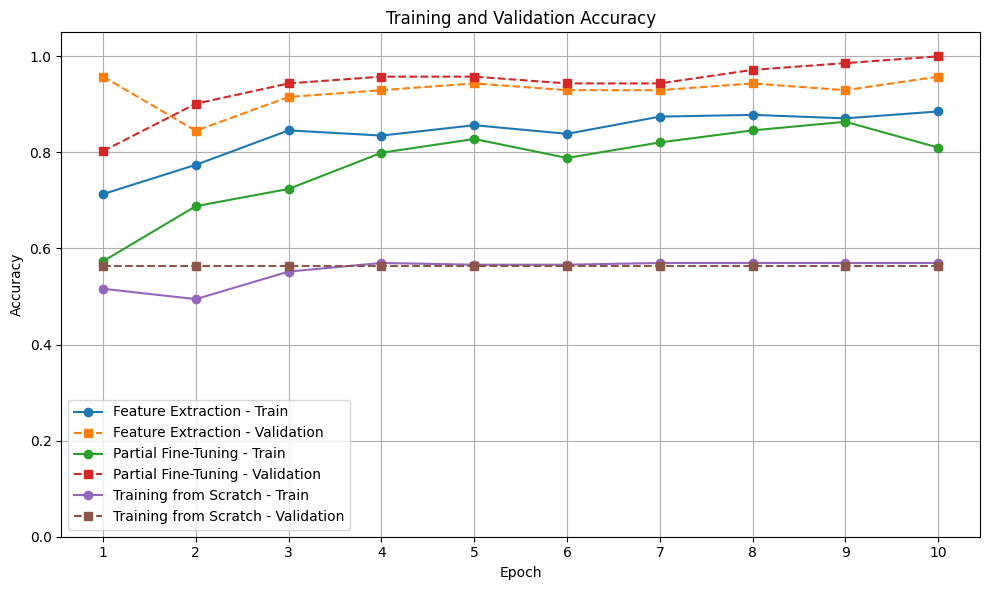

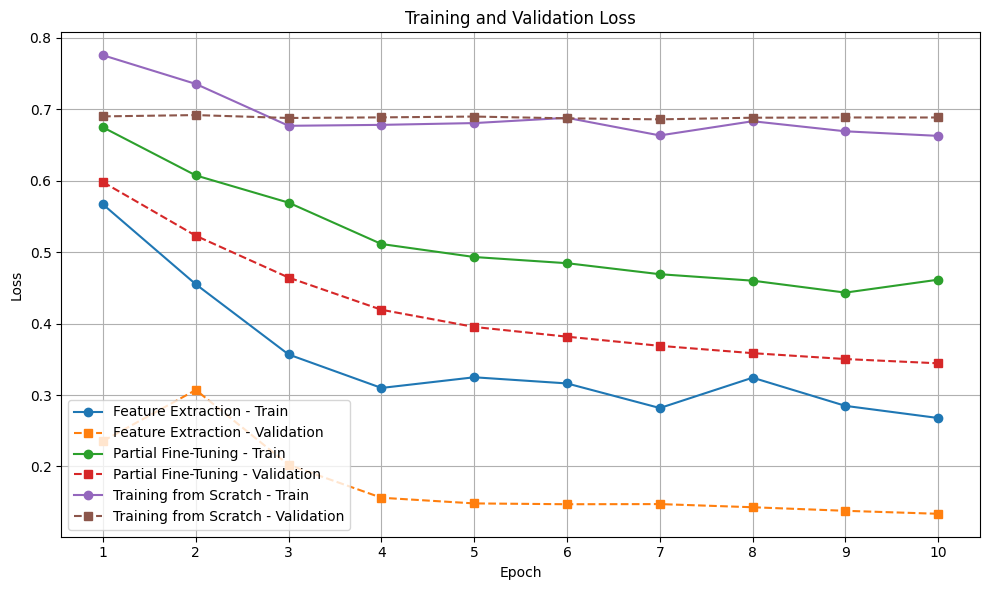

In [ ]:
import matplotlib.pyplot as plt

histories = {
    "Feature Extraction": history_feature,
    "Partial Fine-Tuning": history_partial,
    "Training from Scratch": history_scratch
}

epochs = range(1, 11)

# Grafik Accuracy
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        epochs,
        history["train_acc"],
        marker="o",
        label=f"{name} - Train"
    )
    plt.plot(
        epochs,
        history["val_acc"],
        marker="s",
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("/content/comparison_accuracy.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label=f"{name} - Train"
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="s",
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("/content/comparison_loss.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def evaluate_model(model, loader, title):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=[0, 1]
    )

    print(f"\nClassification Report: {title}")
    print(classification_report(
        all_labels,
        all_preds,
        labels=[0, 1],
        target_names=["fork", "spoon"],
        zero_division=0
    ))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["fork", "spoon"],
        yticklabels=["fork", "spoon"]
    )

    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return cm


Classification Report: Feature Extraction
              precision    recall  f1-score   support

        fork       0.93      1.00      0.96        40
       spoon       1.00      0.90      0.95        31

    accuracy                           0.96        71
   macro avg       0.97      0.95      0.96        71
weighted avg       0.96      0.96      0.96        71



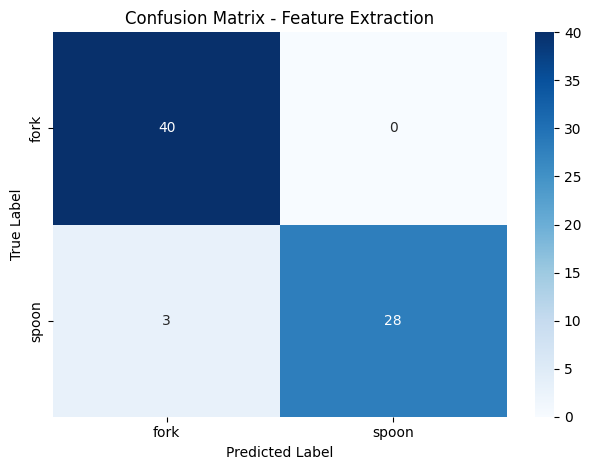


Classification Report: Partial Fine-Tuning
              precision    recall  f1-score   support

        fork       1.00      1.00      1.00        40
       spoon       1.00      1.00      1.00        31

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71



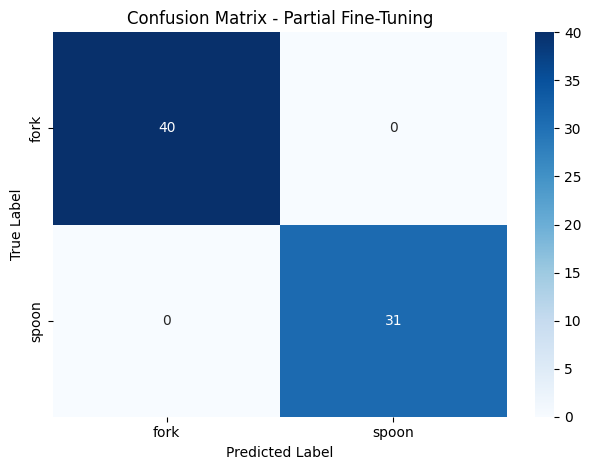


Classification Report: Training from Scratch
              precision    recall  f1-score   support

        fork       0.56      1.00      0.72        40
       spoon       0.00      0.00      0.00        31

    accuracy                           0.56        71
   macro avg       0.28      0.50      0.36        71
weighted avg       0.32      0.56      0.41        71



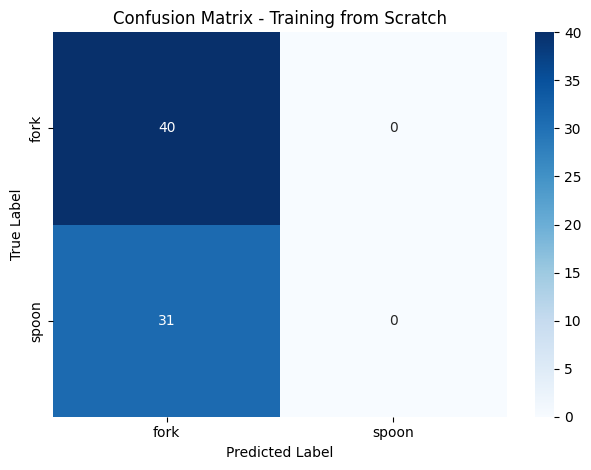

In [ ]:
cm_feature = evaluate_model(
    model_feature, val_loader, "Feature Extraction"
)

cm_partial = evaluate_model(
    model_partial, val_loader, "Partial Fine-Tuning"
)

cm_scratch = evaluate_model(
    model_scratch, val_loader, "Training from Scratch"
)